# Experiment 03 - Post-Lab
## Classification Task on Titanic Dataset
**bold text**
Perform a classification task on the Titanic dataset using Logistic Regression and evaluate the model using accuracy, confusion matrix, precision, recall, and F1-score.

Titanic Dataset Shape: (891, 12)

First Five Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4   

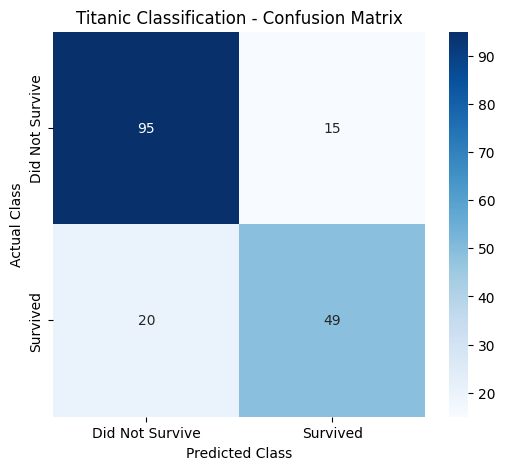


Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       110
       Survived       0.77      0.71      0.74        69

       accuracy                           0.80       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.80      0.80      0.80       179


Feature Importance:
Feature  Coefficient
    Sex     1.296911
 Pclass    -0.893567
    Age    -0.501440
  SibSp    -0.286801
   Fare     0.146436
  Parch    -0.093630


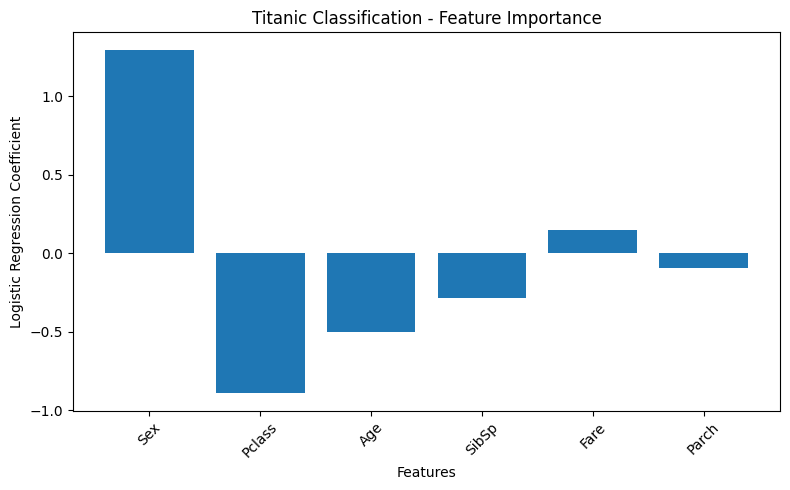


Final Performance Summary:
   Metric    Score
 Accuracy 0.804469
Precision 0.765625
   Recall 0.710145
 F1-Score 0.736842

----------------------------------------
Conclusion
----------------------------------------
The Titanic dataset was successfully classified using Logistic Regression.
The model was evaluated using accuracy, confusion matrix, precision, recall and F1-score.
The results demonstrate the effectiveness of supervised classification for predicting passenger survival.


In [1]:
# Experiment 03 - Post-Lab
# Classification Task on Titanic Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# 1. Load Titanic Dataset
# ---------------------------------------------------------

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic = pd.read_csv(url)

print("Titanic Dataset Shape:", titanic.shape)

print("\nFirst Five Rows:")
print(titanic.head())

# ---------------------------------------------------------
# 2. Select Required Features
# ---------------------------------------------------------

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

X = titanic[features].copy()

y = titanic["Survived"]

# ---------------------------------------------------------
# 3. Handle Missing Values
# ---------------------------------------------------------

X["Age"] = X["Age"].fillna(X["Age"].median())

X["Fare"] = X["Fare"].fillna(X["Fare"].median())

# ---------------------------------------------------------
# 4. Convert Categorical Variable
# ---------------------------------------------------------

X["Sex"] = X["Sex"].map({
    "male": 0,
    "female": 1
})

# ---------------------------------------------------------
# 5. Check Missing Values
# ---------------------------------------------------------

print("\nMissing Values:")
print(X.isnull().sum())

# ---------------------------------------------------------
# 6. Display Target Distribution
# ---------------------------------------------------------

print("\nSurvival Distribution:")
print(y.value_counts())

# ---------------------------------------------------------
# 7. Split Dataset
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTraining Set Shape:", X_train.shape)

print("Testing Set Shape:", X_test.shape)

# ---------------------------------------------------------
# 8. Standardize Features
# ---------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 9. Create Logistic Regression Model
# ---------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# ---------------------------------------------------------
# 10. Train Model
# ---------------------------------------------------------

model.fit(
    X_train_scaled,
    y_train
)

# ---------------------------------------------------------
# 11. Make Predictions
# ---------------------------------------------------------

y_pred = model.predict(
    X_test_scaled
)

# ---------------------------------------------------------
# 12. Calculate Accuracy
# ---------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n----------------------------------------")
print("Titanic Classification Results")
print("----------------------------------------")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

# ---------------------------------------------------------
# 13. Precision
# ---------------------------------------------------------

precision = precision_score(
    y_test,
    y_pred
)

print(
    f"Precision: {precision:.4f}"
)

# ---------------------------------------------------------
# 14. Recall
# ---------------------------------------------------------

recall = recall_score(
    y_test,
    y_pred
)

print(
    f"Recall: {recall:.4f}"
)

# ---------------------------------------------------------
# 15. F1-Score
# ---------------------------------------------------------

f1 = f1_score(
    y_test,
    y_pred
)

print(
    f"F1-Score: {f1:.4f}"
)

# ---------------------------------------------------------
# 16. Confusion Matrix
# ---------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

# ---------------------------------------------------------
# 17. Confusion Matrix Visualization
# ---------------------------------------------------------

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Titanic Classification - Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

# ---------------------------------------------------------
# 18. Classification Report
# ---------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

# ---------------------------------------------------------
# 19. Feature Importance
# ---------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Importance",
    ascending=False
)

print("\nFeature Importance:")
print(
    feature_importance[
        ["Feature", "Coefficient"]
    ].to_string(index=False)
)

# ---------------------------------------------------------
# 20. Feature Importance Visualization
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)

plt.xlabel("Features")

plt.ylabel("Logistic Regression Coefficient")

plt.title("Titanic Classification - Feature Importance")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# 21. Final Performance Summary
# ---------------------------------------------------------

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\nFinal Performance Summary:")

print(
    results.to_string(index=False)
)

# ---------------------------------------------------------
# 22. Conclusion
# ---------------------------------------------------------

print("\n----------------------------------------")
print("Conclusion")
print("----------------------------------------")

print(
    "The Titanic dataset was successfully classified "
    "using Logistic Regression."
)

print(
    "The model was evaluated using accuracy, "
    "confusion matrix, precision, recall and F1-score."
)

print(
    "The results demonstrate the effectiveness of "
    "supervised classification for predicting passenger survival."
)